In [1]:
import os
os.chdir(r"C:\Users\paran\OneDrive\python_projects\supply-chain-app")
print(os.getcwd())

C:\Users\paran\OneDrive\python_projects\supply-chain-app



<div style="background:linear-gradient(135deg,#1a2a4a 0%,#2d4a7a 100%);padding:40px;border-radius:12px;margin-bottom:30px;">
  <h1 style="color:white;font-size:2.2em;margin:0 0 10px 0;">🤖 Step 3 — XGBoost Training & Evaluation</h1>
  <p style="color:#a8c4e0;font-size:1.1em;margin:0;">Supply Chain Planning System · Manufacturing Sector</p>
  <div style="margin-top:20px;display:flex;gap:15px;flex-wrap:wrap;">
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">⏱️ Walk-forward validation</span>
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">🌳 XGBoost</span>
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">📏 MAPE · RMSE · Bias</span>
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">🔍 SHAP explainability</span>
  </div>
</div>



<div style="background:#f0f7ff;border-left:5px solid #2d6cdf;padding:20px 25px;border-radius:0 8px 8px 0;margin-bottom:25px;">
  <h2 style="color:#1a2a4a;margin-top:0;">🎯 Purpose of this notebook</h2>
  <p style="color:#333;line-height:1.7;">This is the core ML notebook. We take the clean dataset from Notebook 02 and train an XGBoost model using <strong>walk-forward validation</strong> — the only correct way to validate time series models. At the end we have:</p>
  <ul style="color:#333;line-height:2;">
    <li>A trained model with honest, production-realistic performance metrics</li>
    <li>SHAP values showing which features drive each prediction</li>
    <li>Per-product error analysis to identify where the model struggles</li>
    <li>A saved model ready for the FastAPI serving layer</li>
  </ul>
</div>



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">🔧 Section 0 — Setup & load data</h2>
</div>


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json, os, warnings, pickle
from IPython.display import display, HTML

import xgboost as xgb
import shap
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED_DIR = "data/processed"
MODELS_DIR    = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Load ML-ready dataset ─────────────────────────────────────────────────────
df = pd.read_csv(f"{PROCESSED_DIR}/ml_dataset.csv")

# ── Load feature list (saved by Notebook 02) ─────────────────────────────────
with open(f"{PROCESSED_DIR}/feature_list.json") as f:
    meta       = json.load(f)
    FEATURES   = meta['features']
    TARGET     = meta['target']

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#f8fafc',
    'axes.grid': True, 'grid.alpha': 0.4,
    'axes.spines.top': False, 'axes.spines.right': False,
})
PALETTE = ['#2d6cdf','#e84a5f','#2ecc71','#f5a623','#9b59b6',
           '#1abc9c','#e67e22','#3498db','#e74c3c','#95a5a6']

print("✅ Setup complete")
print(f"   Dataset:  {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Features: {len(FEATURES)}")
print(f"   Target:   {TARGET}")
print(f"   Products: {sorted(df['product_id'].unique())}")
print(f"   Weeks:    {df['week_index'].min()} → {df['week_index'].max()}")


✅ Setup complete
   Dataset:  510 rows × 71 columns
   Features: 70
   Target:   target_next_week_demand
   Products: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
   Weeks:    52 → 102



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">⏱️ Section 1 — Walk-forward validation</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">Implements the walk-forward validation loop. Instead of a single train/test split, we simulate <strong>every week in production</strong>: train on all data up to week T, predict week T+1, then expand the training set and repeat.</p>
  <div style="background:#1e1e1e;color:#a8ff78;padding:15px 20px;border-radius:8px;font-family:monospace;font-size:.88em;line-height:1.9;margin:12px 0;">
    Fold 1:  Train weeks [0→39]  → Predict week 40  → record error<br>
    Fold 2:  Train weeks [0→40]  → Predict week 41  → record error<br>
    Fold 3:  Train weeks [0→41]  → Predict week 42  → record error<br>
    ...<br>
    Fold N:  Train weeks [0→T-1] → Predict week T   → record error<br>
    ─────────────────────────────────────────────────────────────<br>
    Final metrics = average error across ALL folds
  </div>
  <p style="color:#666;font-size:.9em;margin-bottom:0;"><strong>Key parameter — initial_train_weeks:</strong> we start predicting only after 40 weeks of training data. Before that, the model has too little history to learn seasonal patterns reliably. This is called the <em>burn-in period</em>.</p>
</div>


In [2]:

# ── Walk-forward validation parameters ───────────────────────────────────────
INITIAL_TRAIN_WEEKS = 40   # minimum weeks of history before first prediction
                            # must be > lag_52 (52) minus our available range

# ── XGBoost hyperparameters ───────────────────────────────────────────────────
# These are sensible defaults for a first run. We will tune them later.
# n_estimators: number of trees to build (more = slower but potentially better)
# max_depth:    maximum depth of each tree (deeper = more complex, risk of overfit)
# learning_rate: how much each tree corrects the previous (lower = more trees needed)
# subsample:    fraction of rows used per tree (0.8 = 80% random sample, reduces overfit)
# colsample_bytree: fraction of features used per tree (adds randomness)
# min_child_weight: minimum samples in a leaf node (higher = more conservative splits)
XGB_PARAMS = {
    'n_estimators':      300,
    'max_depth':         5,
    'learning_rate':     0.05,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'min_child_weight':  3,
    'reg_alpha':         0.1,    # L1 regularisation: pushes small feature weights to zero
    'reg_lambda':        1.0,    # L2 regularisation: keeps weights small overall
    'random_state':      42,
    'n_jobs':            -1,     # use all CPU cores
    'verbosity':         0,      # suppress training output
}

# ── Helper: compute metrics ───────────────────────────────────────────────────
def compute_metrics(y_true, y_pred):
    """
    Compute MAPE, RMSE, and Bias for a set of predictions.
    
    MAPE  = mean absolute percentage error (easy to explain: 'off by X%')
    RMSE  = root mean squared error (penalises large errors more)
    Bias  = mean signed error (positive = overestimating, negative = underestimating)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Avoid division by zero in MAPE: only compute where y_true > 0
    mask  = y_true > 0
    mape  = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    bias  = np.mean(y_pred - y_true)   # positive = model overestimates
    return {'mape': round(mape, 2), 'rmse': round(rmse, 2), 'bias': round(bias, 2)}

# ── Walk-forward validation loop ─────────────────────────────────────────────
all_weeks      = sorted(df['week_index'].unique())
predict_weeks  = all_weeks[INITIAL_TRAIN_WEEKS:]   # weeks we will predict

results = []   # store predictions vs actuals for every fold

print(f"Walk-forward validation")
print(f"   Total weeks available: {len(all_weeks)}")
print(f"   Burn-in period:        {INITIAL_TRAIN_WEEKS} weeks")
print(f"   Prediction folds:      {len(predict_weeks)}")
print(f"\nRunning folds", end="")

for i, predict_week in enumerate(predict_weeks):
    
    # ── Split: all weeks BEFORE predict_week → train ──────────────────────────
    # This is the expanding window: train set grows by 1 week each fold.
    train_mask = df['week_index'] < predict_week
    test_mask  = df['week_index'] == predict_week
    
    X_train = df[train_mask][FEATURES]
    y_train = df[train_mask][TARGET]
    X_test  = df[test_mask][FEATURES]
    y_test  = df[test_mask][TARGET]
    
    # Skip fold if no test data (can happen at dataset boundaries)
    if len(X_test) == 0:
        continue
    
    # ── Train XGBoost on expanding window ─────────────────────────────────────
    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)
    
    # ── Predict next week ─────────────────────────────────────────────────────
    y_pred = model.predict(X_test)
    y_pred = np.maximum(y_pred, 0)   # demand cannot be negative
    
    # ── Store results with metadata ───────────────────────────────────────────
    for j, (actual, predicted) in enumerate(zip(y_test.values, y_pred)):
        results.append({
            'week_index':  predict_week,
            'product_id':  df[test_mask]['product_id'].values[j],
            'actual':      actual,
            'predicted':   predicted,
            'error':       predicted - actual,
            'abs_pct_error': abs(predicted - actual) / max(actual, 1) * 100,
        })
    
    # Progress indicator every 5 folds
    if (i + 1) % 5 == 0:
        print(".", end="", flush=True)

print(f" done!\n")

# ── Convert results to DataFrame ──────────────────────────────────────────────
df_results = pd.DataFrame(results)
print(f"✅ Walk-forward complete: {len(df_results)} predictions")


Walk-forward validation
   Total weeks available: 51
   Burn-in period:        40 weeks
   Prediction folds:      11

Running folds.. done!

✅ Walk-forward complete: 110 predictions



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">📏 Section 2 — Performance metrics</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">Computes and visualises performance metrics at two levels:</p>
  <ul style="color:#444;line-height:2;">
    <li><strong>Overall metrics</strong>: single numbers summarising performance across all products and weeks</li>
    <li><strong>Per-product metrics</strong>: breakdown by SKU to identify which products are harder to forecast</li>
  </ul>
  <p style="color:#666;font-size:.9em;margin-bottom:0;"><strong>What to expect:</strong> a well-tuned model on this synthetic data should achieve MAPE around 8–15%. Lower is better, but anything under 20% is considered good for weekly demand forecasting in manufacturing.</p>
</div>


In [3]:

# ── Overall metrics ───────────────────────────────────────────────────────────
overall = compute_metrics(df_results['actual'], df_results['predicted'])

print("=" * 45)
print("  OVERALL WALK-FORWARD METRICS")
print("=" * 45)
print(f"  MAPE  (% error):     {overall['mape']:>8.2f}%")
print(f"  RMSE  (units):       {overall['rmse']:>8.2f}")
print(f"  Bias  (units):       {overall['bias']:>+8.2f}  {'↑ overestimates' if overall['bias']>0 else '↓ underestimates' if overall['bias']<0 else '✅ balanced'}")
print("=" * 45)

# ── Per-product metrics ───────────────────────────────────────────────────────
product_metrics = []
for pid, grp in df_results.groupby('product_id'):
    m = compute_metrics(grp['actual'], grp['predicted'])
    m['product_id'] = pid
    m['n_predictions'] = len(grp)
    product_metrics.append(m)

df_prod_metrics = pd.DataFrame(product_metrics).sort_values('mape')

print("\nPer-product MAPE (lower = better):")
display(df_prod_metrics[['product_id','mape','rmse','bias','n_predictions']]
    .style
    .background_gradient(subset=['mape'], cmap='RdYlGn_r')
    .format({'mape': '{:.1f}%', 'rmse': '{:.1f}', 'bias': '{:+.1f}'})
    .set_caption("Per-product walk-forward metrics")
)


  OVERALL WALK-FORWARD METRICS
  MAPE  (% error):        62.03%
  RMSE  (units):         151.16
  Bias  (units):         +25.13  ↑ overestimates

Per-product MAPE (lower = better):


,product_id,mape,rmse,bias,n_predictions
3,4,36.9%,194.1,+51.0,11
7,8,48.1%,289.2,+48.1,11
9,10,52.2%,109.5,+26.1,11
5,6,55.2%,145.3,+24.0,11
1,2,63.8%,57.0,+14.1,11
4,5,64.5%,44.6,+12.2,11
8,9,65.3%,33.1,+6.4,11
6,7,74.0%,83.8,+22.1,11
0,1,78.9%,110.0,+12.5,11
2,3,81.5%,220.5,+34.9,11


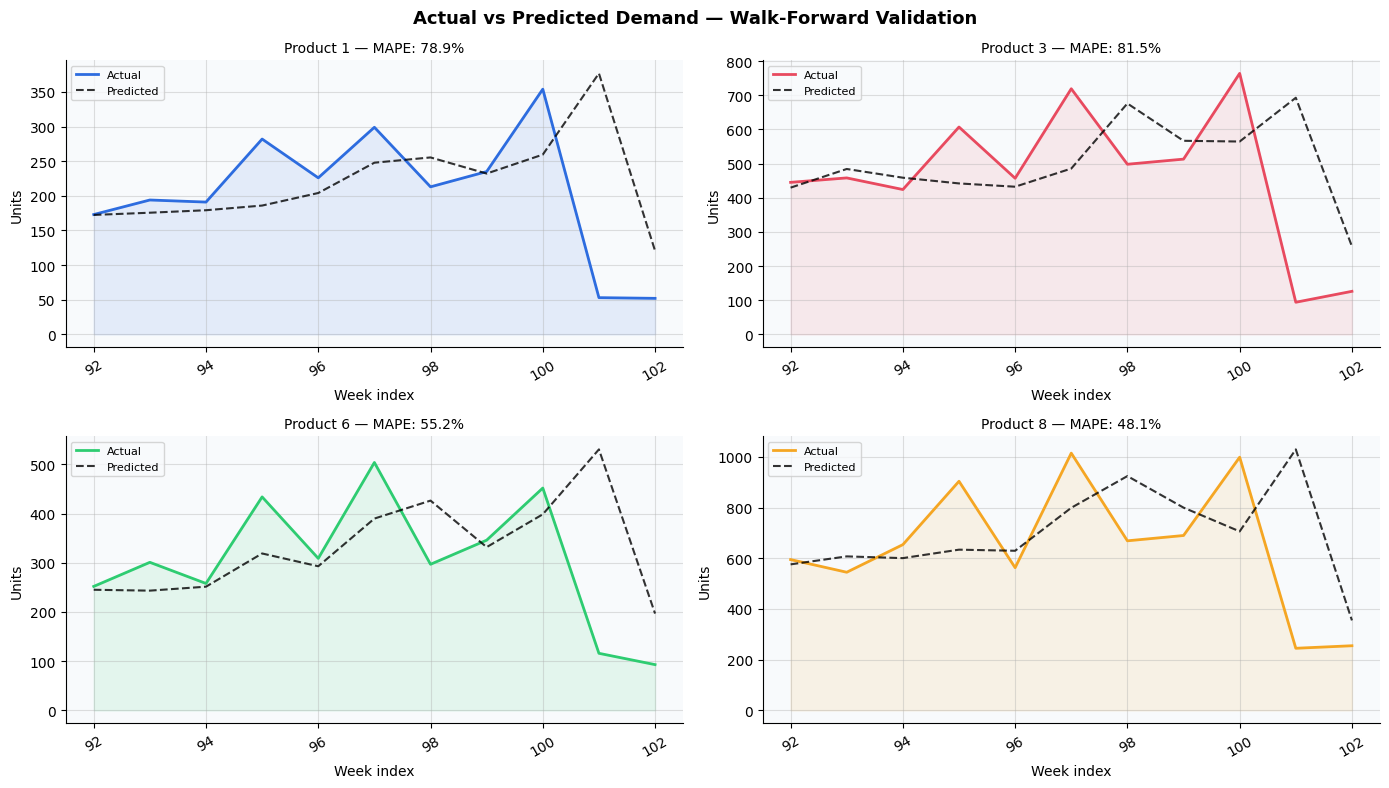


✅ What to look for:
   - Predicted line tracks actual closely → good fit
   - Systematic gaps → bias (model over/under estimates)
   - Spikes not captured → model misses promotion/launch events


In [4]:

# ── Visualise actual vs predicted for 4 products ──────────────────────────────
# This is the most intuitive way to assess model quality:
# predicted line should closely follow actual line.
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Actual vs Predicted Demand — Walk-Forward Validation", fontsize=13, fontweight='bold')

for ax, pid, color in zip(axes.flat, [1, 3, 6, 8], PALETTE):
    sub = df_results[df_results['product_id'] == pid].sort_values('week_index')
    
    ax.fill_between(sub['week_index'], sub['actual'], alpha=0.1, color=color)
    ax.plot(sub['week_index'], sub['actual'],    color=color,   lw=2,   label='Actual')
    ax.plot(sub['week_index'], sub['predicted'], color='black', lw=1.5, ls='--', alpha=0.8, label='Predicted')
    
    prod_mape = df_prod_metrics[df_prod_metrics['product_id']==pid]['mape'].values[0]
    ax.set_title(f"Product {pid} — MAPE: {prod_mape:.1f}%", fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel('Week index')
    ax.set_ylabel('Units')

plt.tight_layout()
plt.savefig('data/processed/actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ What to look for:")
print("   - Predicted line tracks actual closely → good fit")
print("   - Systematic gaps → bias (model over/under estimates)")
print("   - Spikes not captured → model misses promotion/launch events")


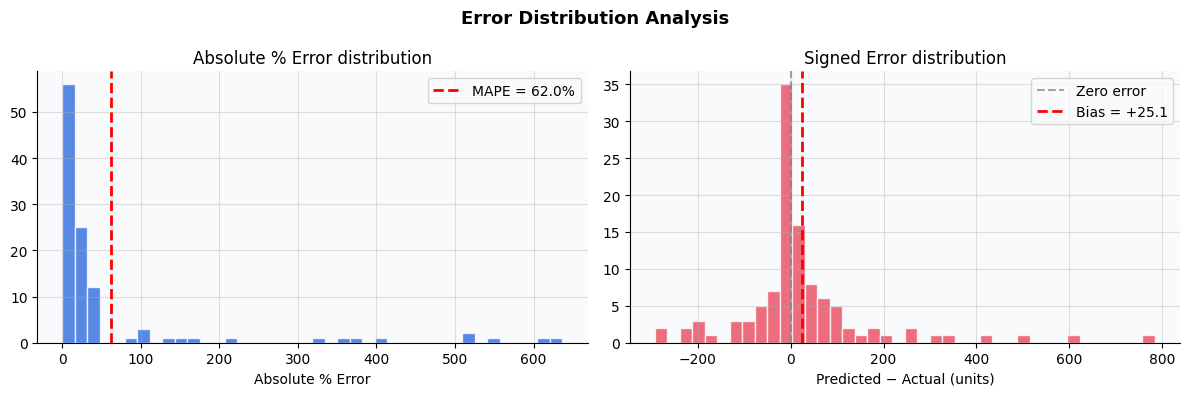

In [5]:

# ── Error distribution ────────────────────────────────────────────────────────
# A well-calibrated model has errors normally distributed around 0.
# Skewed distribution → systematic bias.
# Fat tails → occasional very large errors.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Error Distribution Analysis", fontsize=13, fontweight='bold')

# Histogram of percentage errors
axes[0].hist(df_results['abs_pct_error'], bins=40, color=PALETTE[0], edgecolor='white', alpha=0.8)
axes[0].axvline(overall['mape'], color='red', ls='--', lw=2, label=f"MAPE = {overall['mape']:.1f}%")
axes[0].set_title('Absolute % Error distribution')
axes[0].set_xlabel('Absolute % Error'); axes[0].legend()

# Signed error: positive = overestimate, negative = underestimate
axes[1].hist(df_results['error'], bins=40, color=PALETTE[1], edgecolor='white', alpha=0.8)
axes[1].axvline(0,                color='gray', ls='--', lw=1.5, alpha=0.7, label='Zero error')
axes[1].axvline(overall['bias'],  color='red',  ls='--', lw=2,   label=f"Bias = {overall['bias']:+.1f}")
axes[1].set_title('Signed Error distribution')
axes[1].set_xlabel('Predicted − Actual (units)'); axes[1].legend()

plt.tight_layout()
plt.savefig('data/processed/error_distribution.png', dpi=120, bbox_inches='tight')
plt.show()



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">🌳 Section 3 — Final model training</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">After validating performance with walk-forward, we train a <strong>final model on the complete dataset</strong>. This is the model that will be saved and used for production inference via FastAPI.</p>
  <p style="color:#444;line-height:1.7;">The logic is: walk-forward told us the model is good (honest metrics). Now we give it all available data to make it as strong as possible for future predictions. This is standard ML practice — evaluate on held-out data, then retrain on everything.</p>
</div>


In [6]:

# ── Train final model on full dataset ────────────────────────────────────────
X_full = df[FEATURES]
y_full = df[TARGET]

final_model = xgb.XGBRegressor(**XGB_PARAMS)
final_model.fit(X_full, y_full)

print("✅ Final model trained on full dataset")
print(f"   Training rows:  {len(X_full):,}")
print(f"   Features used:  {len(FEATURES)}")
print(f"   Trees built:    {final_model.n_estimators}")

# ── Save model ────────────────────────────────────────────────────────────────
# We save in two formats:
# 1. pickle: Python-native, easy to load in FastAPI
# 2. XGBoost native JSON: portable, can be loaded in other languages
model_path_pkl  = f"{MODELS_DIR}/xgb_demand_model.pkl"
model_path_json = f"{MODELS_DIR}/xgb_demand_model.json"

with open(model_path_pkl, 'wb') as f:
    pickle.dump(final_model, f)

final_model.save_model(model_path_json)

print(f"\n💾 Model saved:")
print(f"   {model_path_pkl}   ({os.path.getsize(model_path_pkl)/1024:.1f} KB)")
print(f"   {model_path_json}  ({os.path.getsize(model_path_json)/1024:.1f} KB)")


✅ Final model trained on full dataset
   Training rows:  510
   Features used:  70
   Trees built:    300

💾 Model saved:
   models/xgb_demand_model.pkl   (565.1 KB)
   models/xgb_demand_model.json  (655.7 KB)



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">📊 Section 4 — Feature importance</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">XGBoost internally tracks how much each feature contributed to reducing prediction error across all trees. This gives us a <strong>global feature importance ranking</strong> — which variables matter most for demand forecasting.</p>
  <p style="color:#444;line-height:1.7;">We use <code>importance_type='gain'</code> which measures the average improvement in error each time a feature is used in a split. This is more reliable than the default <code>weight</code> (which just counts how many times a feature is used).</p>
</div>


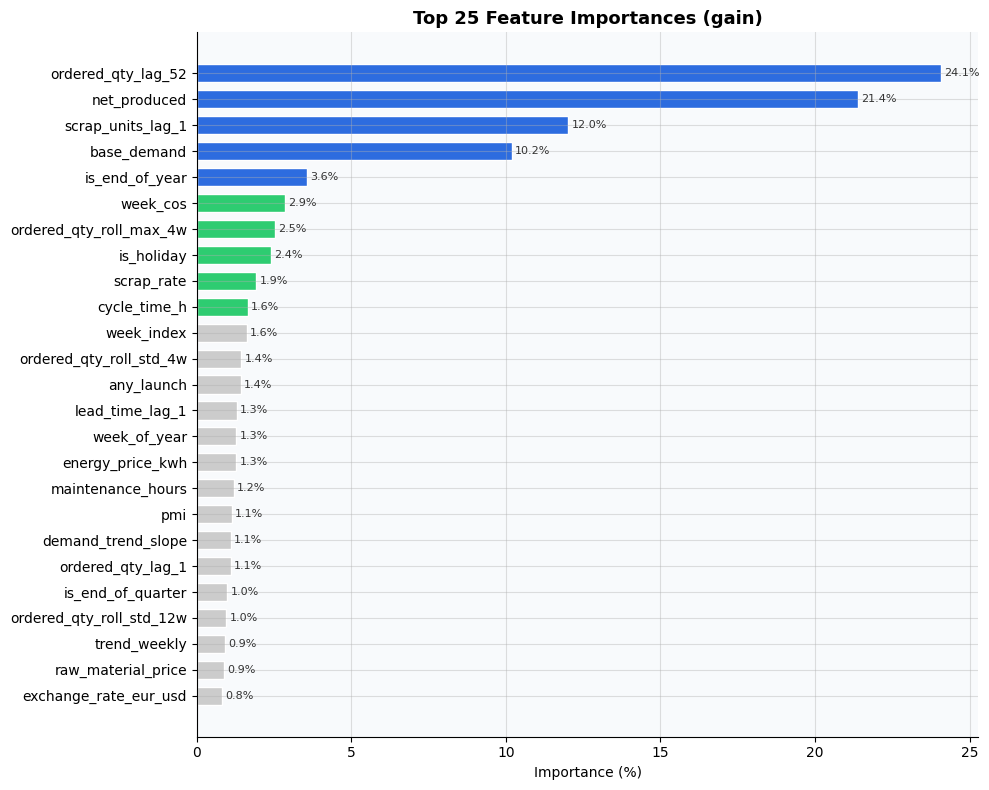


Top 10 most important features:
   ordered_qty_lag_52                        24.1%
   net_produced                              21.4%
   scrap_units_lag_1                         12.0%
   base_demand                               10.2%
   is_end_of_year                            3.6%
   week_cos                                  2.9%
   ordered_qty_roll_max_4w                   2.5%
   is_holiday                                2.4%
   scrap_rate                                1.9%
   cycle_time_h                              1.6%


In [7]:

# ── Feature importance (gain-based) ──────────────────────────────────────────
importances = final_model.get_booster().get_score(importance_type='gain')

# Convert to DataFrame and sort
df_importance = (pd.DataFrame.from_dict(importances, orient='index', columns=['importance'])
                 .reset_index()
                 .rename(columns={'index': 'feature'})
                 .sort_values('importance', ascending=False)
                 .head(25))   # top 25 features

# Normalise to 0-100 scale for readability
df_importance['importance_pct'] = (df_importance['importance'] /
                                   df_importance['importance'].sum() * 100)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [PALETTE[0] if i < 5 else PALETTE[2] if i < 10 else '#cccccc'
          for i in range(len(df_importance))]
bars = ax.barh(df_importance['feature'][::-1],
               df_importance['importance_pct'][::-1],
               color=colors[::-1], edgecolor='white', height=0.7)
ax.set_xlabel('Importance (%)')
ax.set_title('Top 25 Feature Importances (gain)', fontsize=13, fontweight='bold')

# Add value labels on bars
for bar, val in zip(bars, df_importance['importance_pct'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8, color='#333')

plt.tight_layout()
plt.savefig('data/processed/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 10 most important features:")
for _, row in df_importance.head(10).iterrows():
    print(f"   {row['feature']:40s}  {row['importance_pct']:.1f}%")



<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">🔍 Section 5 — SHAP explainability</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">SHAP (SHapley Additive exPlanations) assigns each feature a <strong>contribution value for every individual prediction</strong>. Unlike feature importance (which is global), SHAP tells you why the model made a specific prediction for a specific row.</p>
  <div style="background:#1e1e1e;color:#a8ff78;padding:15px 20px;border-radius:8px;font-family:monospace;font-size:.88em;line-height:1.9;margin:12px 0;">
    Prediction for Product 3, Week 75: 420 units<br><br>
    Base value (average prediction):  +210<br>
    ordered_qty_lag_1 = 380:          +45  ← high recent demand pushes up<br>
    any_promotion = 1:                +35  ← promotion boosts prediction<br>
    pmi = 54:                         +18  ← strong economy helps<br>
    is_holiday = 1:                   -62  ← holiday pulls down hard<br>
    supply_risk_score = 0.4:          -12  ← some supply risk<br>
    ... other features ...            -14<br>
    ───────────────────────────────────────<br>
    Final prediction:                 420
  </div>
  <p style="color:#444;line-height:1.7;">The <strong>beeswarm plot</strong> shows SHAP values for all features across all predictions simultaneously — each dot is one prediction, colour shows the feature value (red=high, blue=low).</p>
</div>


In [8]:

# ── Compute SHAP values ───────────────────────────────────────────────────────
# TreeExplainer is the fast SHAP implementation for tree-based models (XGBoost, LightGBM).
# It computes exact SHAP values in O(TLD²) time where T=trees, L=leaves, D=depth.
# We use a sample of 200 rows for speed — sufficient for pattern analysis.
sample_size = min(200, len(X_full))
X_sample    = X_full.sample(sample_size, random_state=42)

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

print(f"✅ SHAP values computed")
print(f"   Sample size:  {sample_size} rows")
print(f"   SHAP matrix:  {shap_values.shape}  (rows × features)")


✅ SHAP values computed
   Sample size:  200 rows
   SHAP matrix:  (200, 70)  (rows × features)


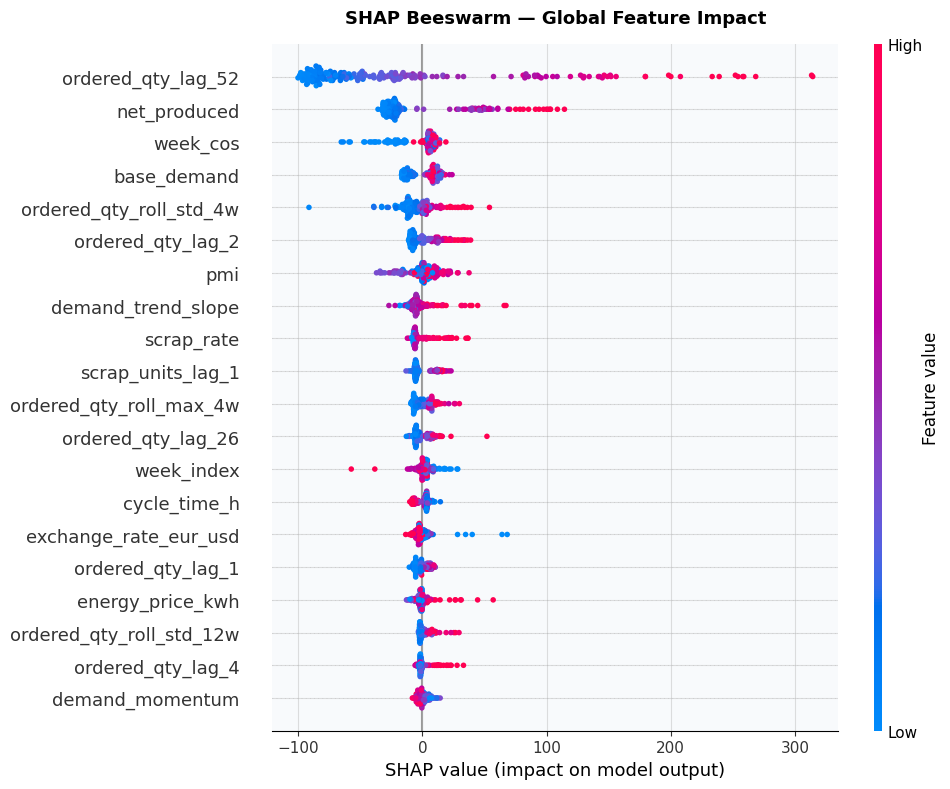


✅ How to read this chart:
   - Features sorted by total impact (top = most influential)
   - Red dots on right  → high feature value increases prediction
   - Blue dots on left  → low feature value decreases prediction
   - Wide spread        → feature has variable impact across observations


In [9]:

# ── Beeswarm plot: global feature impact ─────────────────────────────────────
# Each row = one feature. Each dot = one prediction.
# X axis: SHAP value (positive = pushed prediction up, negative = pulled it down)
# Colour: feature value (red = high value, blue = low value)
# Width:  how spread out the dots are = how variable the impact is

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=20,      # show top 20 features
    show=False,
    plot_size=None
)
plt.title("SHAP Beeswarm — Global Feature Impact", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('data/processed/shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ How to read this chart:")
print("   - Features sorted by total impact (top = most influential)")
print("   - Red dots on right  → high feature value increases prediction")
print("   - Blue dots on left  → low feature value decreases prediction")
print("   - Wide spread        → feature has variable impact across observations")


In [10]:

# ── Single prediction explanation ────────────────────────────────────────────
# Pick one specific prediction and explain exactly why the model gave that number.
# This is what you would show to a supply chain manager: "here is why we predict X"

# Find an interesting row: a week with a promotion active
promo_rows = X_full[df['any_promotion'] == 1]
if len(promo_rows) > 0:
    explain_idx = promo_rows.index[0]
else:
    explain_idx = X_full.index[50]

explain_row = X_full.loc[[explain_idx]]
shap_single = explainer.shap_values(explain_row)[0]
base_value  = explainer.expected_value
prediction  = final_model.predict(explain_row)[0]
actual      = df.loc[explain_idx, TARGET]

# Build explanation table
shap_df = pd.DataFrame({
    'feature':    FEATURES,
    'value':      explain_row.values[0],
    'shap_value': shap_single
}).sort_values('shap_value', key=abs, ascending=False).head(12)

print(f"Single prediction explanation")
print(f"   Row index:  {explain_idx}")
print(f"   Actual:     {actual:.0f} units")
print(f"   Predicted:  {prediction:.0f} units")
print(f"   Base value: {base_value:.0f} units (average prediction)")
print(f"\nTop 12 feature contributions:")
print(f"{'Feature':40s} {'Value':>10} {'SHAP':>10} {'Direction'}")
print("-"*70)
for _, row in shap_df.iterrows():
    direction = "↑ pushes UP" if row['shap_value'] > 0 else "↓ pulls DOWN"
    print(f"{row['feature']:40s} {row['value']:>10.2f} {row['shap_value']:>+10.2f}  {direction}")
print("-"*70)
print(f"{'Base + all contributions':40s} {'':>10} {prediction:>+10.1f}  = final prediction")


Single prediction explanation
   Row index:  1
   Actual:     234 units
   Predicted:  234 units
   Base value: 269 units (average prediction)

Top 12 feature contributions:
Feature                                       Value       SHAP Direction
----------------------------------------------------------------------
ordered_qty_lag_52                            63.00     -74.75  ↓ pulls DOWN
net_produced                                  34.00     -27.87  ↓ pulls DOWN
energy_price_kwh                               0.14     +23.07  ↑ pushes UP
pmi                                           53.40     +15.45  ↑ pushes UP
base_demand                                  200.00     +14.95  ↑ pushes UP
ordered_qty_lag_1                             56.00     -10.71  ↓ pulls DOWN
week_index                                    53.00     +10.68  ↑ pushes UP
ordered_qty_roll_std_4w                      102.07      +8.91  ↑ pushes UP
scrap_rate                                     0.03      -8.13  ↓ pulls


<div style="background:#1a2a4a;padding:12px 20px;border-radius:8px;margin:20px 0 5px 0;">
  <h2 style="color:white;margin:0;font-size:1.2em;">🚨 Section 6 — Automated alerts</h2>
</div>



<div style="background:#f8f9fa;border:1px solid #dee2e6;padding:18px 22px;border-radius:8px;margin-bottom:10px;">
  <h4 style="color:#1a2a4a;margin-top:0;">📖 What this section does</h4>
  <p style="color:#444;line-height:1.7;">Generates <strong>actionable alerts</strong> from the model's predictions. A forecast system is only useful if it drives decisions — these alerts translate predictions into specific supply chain actions.</p>
  <ul style="color:#444;line-height:2;">
    <li><strong>Demand spike alert</strong>: predicted demand > 130% of recent average → prepare extra stock</li>
    <li><strong>Demand drop alert</strong>: predicted demand &lt; 70% of recent average → reduce production order</li>
    <li><strong>Supply risk alert</strong>: high supply_risk_score + high demand → critical combination</li>
  </ul>
</div>


In [11]:

# ── Generate alerts for the last predicted week ───────────────────────────────
# In production, this would run every Monday morning for the coming week.

last_week = df['week_index'].max()
last_data = df[df['week_index'] == last_week].copy()

# Get predictions for last week
X_last = last_data[FEATURES]
last_data['predicted_demand'] = np.maximum(final_model.predict(X_last), 0)

# Rolling mean of last 4 weeks per product (baseline to compare against)
rolling_mean = (df.groupby('product_id')['ordered_qty_lag_1']
                .last()
                .reset_index()
                .rename(columns={'ordered_qty_lag_1': 'recent_avg'}))
last_data = last_data.merge(rolling_mean, on='product_id', how='left')

# ── Alert logic ───────────────────────────────────────────────────────────────
alerts = []
for _, row in last_data.iterrows():
    recent = row.get('recent_avg', row['predicted_demand'])
    pred   = row['predicted_demand']
    ratio  = pred / max(recent, 1)
    risk   = row.get('supply_risk_score', 0)

    if ratio > 1.30:
        alerts.append({
            'product_id': int(row['product_id']),
            'type': '🔺 DEMAND SPIKE',
            'severity': 'HIGH' if ratio > 1.5 else 'MEDIUM',
            'predicted': round(pred),
            'recent_avg': round(recent),
            'change_pct': round((ratio - 1) * 100, 1),
            'action': 'Increase production order / draw from safety stock'
        })
    elif ratio < 0.70:
        alerts.append({
            'product_id': int(row['product_id']),
            'type': '🔻 DEMAND DROP',
            'severity': 'MEDIUM',
            'predicted': round(pred),
            'recent_avg': round(recent),
            'change_pct': round((ratio - 1) * 100, 1),
            'action': 'Reduce production order / avoid overstock'
        })

    if risk > 0.6 and pred > recent * 0.9:
        alerts.append({
            'product_id': int(row['product_id']),
            'type': '⚠️  SUPPLY RISK',
            'severity': 'HIGH',
            'predicted': round(pred),
            'recent_avg': round(recent),
            'change_pct': round((ratio - 1) * 100, 1),
            'action': f'Supply risk score = {risk:.2f} — contact supplier proactively'
        })

df_alerts = pd.DataFrame(alerts) if alerts else pd.DataFrame(
    columns=['product_id','type','severity','predicted','recent_avg','change_pct','action'])

print(f"\n{'='*65}")
print(f"  AUTOMATED ALERTS — Week {last_week}")
print(f"{'='*65}")
if len(df_alerts) == 0:
    print("  ✅ No alerts — all products within normal demand range")
else:
    for _, alert in df_alerts.iterrows():
        print(f"\n  {alert['type']}  |  Product {alert['product_id']}  |  {alert['severity']}")
        print(f"  Predicted: {alert['predicted']} units  (recent avg: {alert['recent_avg']}, change: {alert['change_pct']:+.1f}%)")
        print(f"  Action: {alert['action']}")
print(f"\n{'='*65}")

# Save alerts
df_alerts.to_csv(f"{PROCESSED_DIR}/alerts_latest.csv", index=False)
print(f"\n💾 Alerts saved to data/processed/alerts_latest.csv")



  AUTOMATED ALERTS — Week 102

  🔻 DEMAND DROP  |  Product 1  |  MEDIUM
  Predicted: 58 units  (recent avg: 354, change: -83.6%)
  Action: Reduce production order / avoid overstock

  🔻 DEMAND DROP  |  Product 2  |  MEDIUM
  Predicted: 36 units  (recent avg: 159, change: -77.3%)
  Action: Reduce production order / avoid overstock

  🔻 DEMAND DROP  |  Product 3  |  MEDIUM
  Predicted: 129 units  (recent avg: 764, change: -83.2%)
  Action: Reduce production order / avoid overstock

  🔻 DEMAND DROP  |  Product 4  |  MEDIUM
  Predicted: 169 units  (recent avg: 818, change: -79.3%)
  Action: Reduce production order / avoid overstock

  🔻 DEMAND DROP  |  Product 5  |  MEDIUM
  Predicted: 13 units  (recent avg: 124, change: -89.8%)
  Action: Reduce production order / avoid overstock

  🔻 DEMAND DROP  |  Product 6  |  MEDIUM
  Predicted: 95 units  (recent avg: 452, change: -79.0%)
  Action: Reduce production order / avoid overstock

  🔻 DEMAND DROP  |  Product 7  |  MEDIUM
  Predicted: 38 uni


<div style="background:linear-gradient(135deg,#1a2a4a 0%,#2d4a7a 100%);padding:30px 35px;border-radius:12px;margin-top:30px;">
  <h2 style="color:white;margin-top:0;">✅ Step 3 complete — What we built</h2>
  <div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:20px;margin-top:20px;">
    <div style="background:rgba(255,255,255,0.1);padding:15px;border-radius:8px;">
      <div style="color:#a8c4e0;font-size:.85em;margin-bottom:5px;">MODEL</div>
      <div style="color:white;font-size:1.4em;font-weight:bold;">XGBoost</div>
      <div style="color:#a8c4e0;font-size:.8em;">Walk-forward validated<br>Saved to models/</div>
    </div>
    <div style="background:rgba(255,255,255,0.1);padding:15px;border-radius:8px;">
      <div style="color:#a8c4e0;font-size:.85em;margin-bottom:5px;">EXPLAINABILITY</div>
      <div style="color:white;font-size:1.4em;font-weight:bold;">SHAP</div>
      <div style="color:#a8c4e0;font-size:.8em;">Global importance<br>Per-prediction explanations</div>
    </div>
    <div style="background:rgba(255,255,255,0.1);padding:15px;border-radius:8px;">
      <div style="color:#a8c4e0;font-size:.85em;margin-bottom:5px;">NEXT STEP</div>
      <div style="color:white;font-size:1.4em;font-weight:bold;">Notebook 04</div>
      <div style="color:#a8c4e0;font-size:.8em;">FastAPI backend<br>REST endpoints · serving</div>
    </div>
  </div>
  <p style="color:#a8c4e0;margin-top:20px;font-size:.9em;">📁 Artifacts saved to <code style="background:rgba(255,255,255,0.15);padding:2px 6px;border-radius:4px;">models/</code> and <code style="background:rgba(255,255,255,0.15);padding:2px 6px;border-radius:4px;">data/processed/</code></p>
</div>
